# Assignment 4 – Machine Learning for Threat Detection


This notebook demonstrates the complete workflow for developing a machine learning-based network intrusion detection system using a synthetic cybersecurity dataset.

In [1]:
import pandas as pd

df = pd.read_csv("synthetic_data/synthetic_network_data_20260803_034339.csv")

df.head()

,flow_id,timestamp,duration,protocol_type,service,flag,src_ip,dst_ip,src_port,dst_port,fwd_packets,bwd_packets,total_packets,fwd_bytes,bwd_bytes,total_bytes,flow_bytes_s,flow_packets_s,label,attack_type
0,1,2026-07-20 19:32:47,37.117862,TCP,HTTP,REJ,192.168.1.61,198.51.100.187,5350,80,14,11,25,20468,3993,24461,659.01,0.67,Benign,Benign
1,2,2026-07-21 01:30:17,9.819670,TCP,HTTPS,RSTO,192.168.1.20,192.0.2.66,16796,25,13,7,20,12051,3374,15425,1570.83,2.04,Benign,Benign
2,3,2026-07-20 18:33:57,25.250553,TCP,HTTP,OTH,172.16.0.214,198.51.100.171,26170,25,2,2,4,1854,2292,4146,164.19,0.16,Benign,Benign
3,4,2026-07-20 11:23:20,20.264266,UDP,FTP,S0,10.0.0.238,192.0.2.132,34422,22,10,13,23,4660,1937,6597,325.55,1.14,Benign,Benign
4,5,2026-07-21 01:36:08,78.918283,TCP,OTHER,SF,10.0.0.194,192.0.2.252,5780,119,12,12,24,1764,16092,17856,226.26,0.30,Benign,Benign


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flow_id         50000 non-null  int64  
 1   timestamp       50000 non-null  str    
 2   duration        50000 non-null  float64
 3   protocol_type   50000 non-null  str    
 4   service         50000 non-null  str    
 5   flag            50000 non-null  str    
 6   src_ip          50000 non-null  str    
 7   dst_ip          50000 non-null  str    
 8   src_port        50000 non-null  int64  
 9   dst_port        50000 non-null  int64  
 10  fwd_packets     50000 non-null  int64  
 11  bwd_packets     50000 non-null  int64  
 12  total_packets   50000 non-null  int64  
 13  fwd_bytes       50000 non-null  int64  
 14  bwd_bytes       50000 non-null  int64  
 15  total_bytes     50000 non-null  int64  
 16  flow_bytes_s    50000 non-null  float64
 17  flow_packets_s  50000 non-null  float64
 1

In [3]:
df.describe()

,flow_id,duration,src_port,dst_port,fwd_packets,bwd_packets,total_packets,fwd_bytes,bwd_bytes,total_bytes,flow_bytes_s,flow_packets_s
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,5.000000e+04,5.000000e+04,50000.000000
mean,25000.500000,38.151595,33035.847460,140.073460,10.793500,7.610540,842.026760,7379.057180,5882.06358,2.583653e+05,8.569206e+04,831.159967
std,14433.901067,46.554626,18660.545423,191.352912,7.268634,3.841796,2200.588498,5847.716372,4644.92320,7.126781e+05,2.386493e+05,2209.333162
min,1.000000,0.000788,1026.000000,1.000000,1.000000,1.000000,2.000000,40.000000,40.00000,1.000000e+02,1.960000e+00,0.010000
25%,12500.750000,4.874170,16807.000000,22.000000,6.000000,5.000000,12.000000,2620.000000,2104.00000,6.804750e+03,1.746375e+02,0.260000
50%,25000.500000,22.773383,32874.000000,80.000000,10.000000,8.000000,18.000000,6024.000000,4820.00000,1.301850e+04,4.639900e+02,0.630000
75%,37500.250000,53.439744,49233.250000,119.000000,14.000000,10.000000,26.000000,10845.250000,8603.25000,2.202900e+04,2.148212e+03,2.810000
max,50000.000000,531.819207,65535.000000,1024.000000,50.000000,25.000000,9999.000000,37968.000000,37100.00000,4.992000e+06,1.179018e+07,20296.820000


In [4]:
df.isnull().sum()

flow_id           0
timestamp         0
duration          0
protocol_type     0
service           0
flag              0
src_ip            0
dst_ip            0
src_port          0
dst_port          0
fwd_packets       0
bwd_packets       0
total_packets     0
fwd_bytes         0
bwd_bytes         0
total_bytes       0
flow_bytes_s      0
flow_packets_s    0
label             0
attack_type       0
dtype: int64

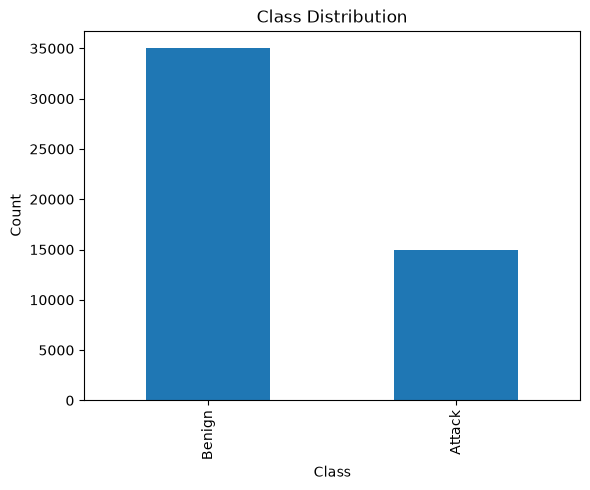

In [5]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

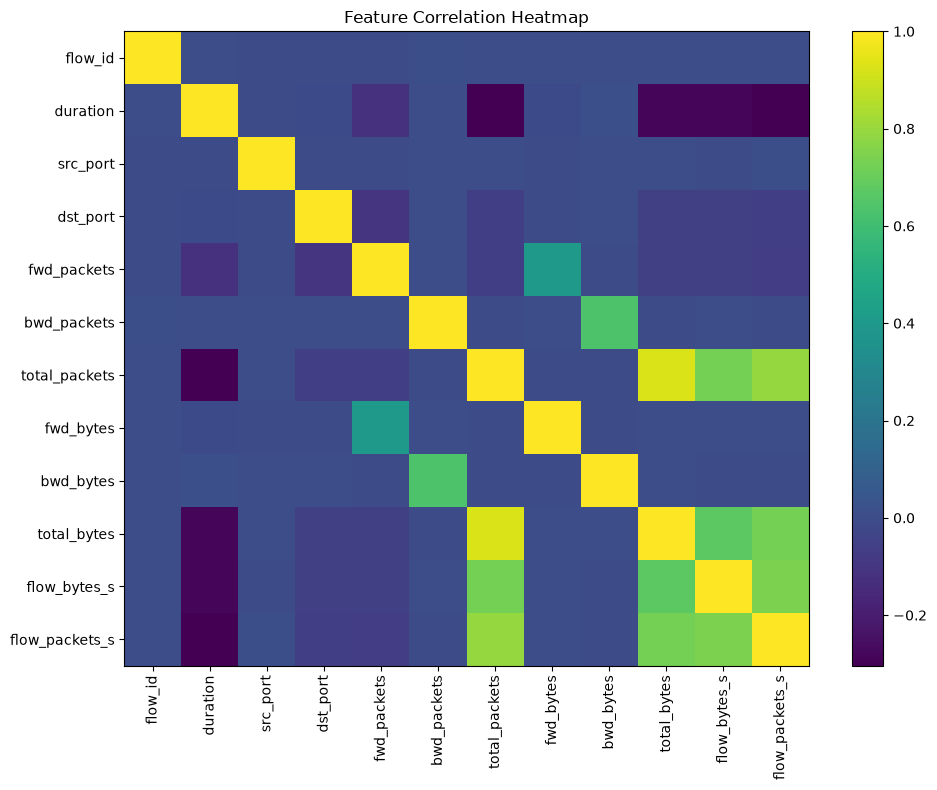

In [6]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

plt.imshow(numeric_df.corr(), aspect="auto")

plt.colorbar()

plt.xticks(range(len(numeric_df.columns)),
           numeric_df.columns,
           rotation=90)

plt.yticks(range(len(numeric_df.columns)),
           numeric_df.columns)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.show()

In [7]:
feature_importance = pd.read_csv(
    "model_artifacts/feature_importance.csv"
)

feature_importance.head(10)

,Feature,Score
0,num__total_bytes,0.399398
1,num__total_packets,0.371234
2,num__duration,0.238679
3,num__flow_packets_s,0.211808
4,num__flow_bytes_s,0.209073
5,cat__flag_S0,0.182195
6,cat__flag_SF,0.165885
7,num__dst_port,0.150560
8,cat__flag_REJ,0.054124
9,num__fwd_packets,0.052811


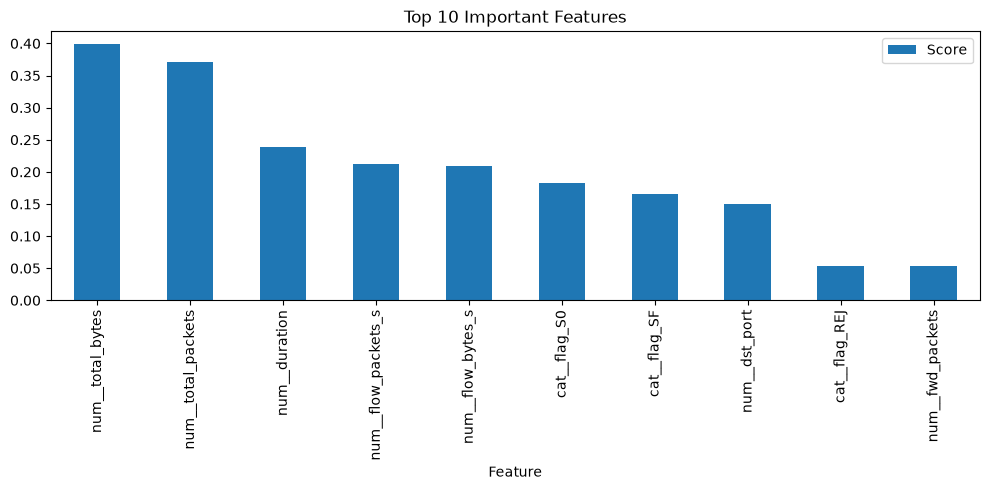

In [8]:
feature_importance.head(10).plot(
    x="Feature",
    y="Score",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Important Features")

plt.tight_layout()

plt.show()